# Baseline Models

Week 3 objectives

In [10]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
np.random.seed(42)


In [11]:
SRC_PATH = Path.cwd() / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from project_utils import compute_regression_metrics, ensure_dir, ensure_processed_data


In [12]:
data_parts = ensure_processed_data(data_dir="data", processed_dir="data/processed", random_state=42)
train_df = data_parts["train"]
val_df = data_parts["val"]
test_df = data_parts["test"]

print("Train/Val/Test shapes:", train_df.shape, val_df.shape, test_df.shape)


Train/Val/Test shapes: (91259, 14) (19556, 14) (19556, 14)


In [13]:
target = "danceability"
if target not in train_df.columns:
    raise ValueError(f"'{target}' not found. Run dataclean.ipynb and confirm dataset columns.")

feature_cols = [c for c in train_df.columns if c != target]
X_train, y_train = train_df[feature_cols], train_df[target]
X_val, y_val = val_df[feature_cols], val_df[target]
X_test, y_test = test_df[feature_cols], test_df[target]

print(f"Target: {target}")
print(f"Feature count: {len(feature_cols)}")


Target: danceability
Feature count: 13


In [14]:
models = {
    "mean_baseline": DummyRegressor(strategy="mean"),
    "linear_regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("linearregression", LinearRegression()),
        ]
    ),
}

scoring = {
    "mse": "neg_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

rows = []
test_predictions = {}
fitted_models = {}

for model_name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=kfold, scoring=scoring)

    fitted = model.fit(X_train, y_train)
    fitted_models[model_name] = fitted

    val_pred = fitted.predict(X_val)
    test_pred = fitted.predict(X_test)
    test_predictions[model_name] = test_pred

    val_metrics = compute_regression_metrics(y_val, val_pred)
    test_metrics = compute_regression_metrics(y_test, test_pred)

    rows.append(
        {
            "target": target,
            "model": model_name,
            "split": "validation",
            **val_metrics,
            "cv_mse": -cv["test_mse"].mean(),
            "cv_mae": -cv["test_mae"].mean(),
            "cv_r2": cv["test_r2"].mean(),
        }
    )
    rows.append(
        {
            "target": target,
            "model": model_name,
            "split": "test",
            **test_metrics,
            "cv_mse": -cv["test_mse"].mean(),
            "cv_mae": -cv["test_mae"].mean(),
            "cv_r2": cv["test_r2"].mean(),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values(["split", "mse"])
metrics_df


/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/oliviaye/Downloads/yale3/CPSC3810/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/olivia

,target,model,split,mse,mae,r2,cv_mse,cv_mae,cv_r2
3,danceability,linear_regression,test,0.020519,0.114989,4.179489e-01,0.020565,0.115347,0.421151
1,danceability,mean_baseline,test,0.035253,0.152924,-8.320265e-07,0.035528,0.153858,-0.000003
2,danceability,linear_regression,validation,0.020462,0.114973,4.201414e-01,0.020565,0.115347,0.421151
0,danceability,mean_baseline,validation,0.035289,0.153125,-3.572663e-06,0.035528,0.153858,-0.000003


In [15]:
outputs_dir = ensure_dir("outputs")
metrics_path = outputs_dir / "baseline_danceability_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics -> {metrics_path}")


Saved metrics -> outputs/baseline_danceability_metrics.csv


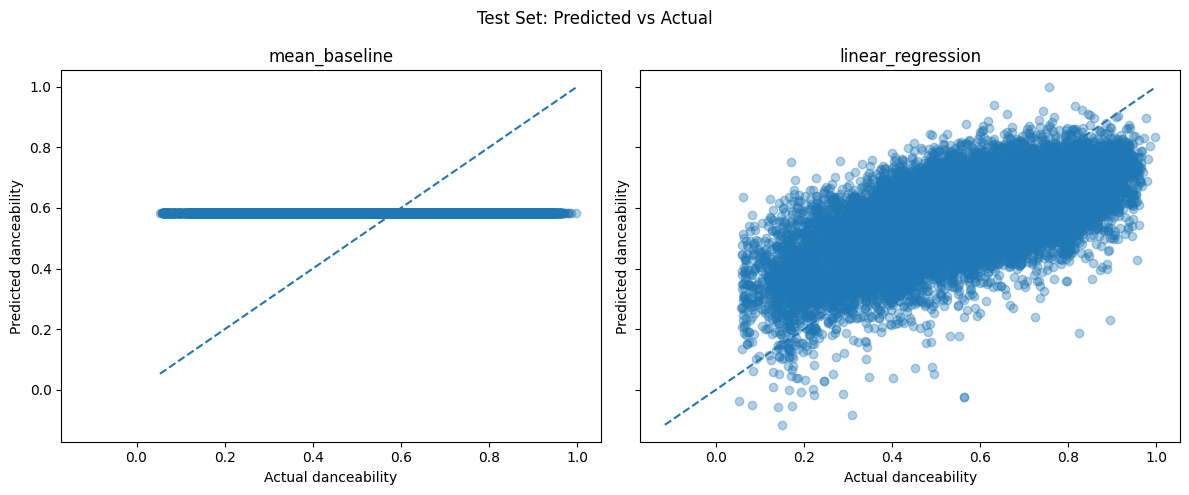

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, (model_name, y_pred) in zip(axes, test_predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.35)
    min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    ax.set_title(model_name)
    ax.set_xlabel("Actual danceability")
    ax.set_ylabel("Predicted danceability")

plt.suptitle("Test Set: Predicted vs Actual")
plt.tight_layout()
plt.show()


In [17]:
linear_model = fitted_models["linear_regression"]
coefs = pd.Series(
    linear_model.named_steps["linearregression"].coef_,
    index=feature_cols,
).sort_values(key=np.abs, ascending=False)

coef_df = coefs.rename("coefficient").reset_index().rename(columns={"index": "feature"})
coef_path = outputs_dir / "baseline_danceability_coefficients.csv"
coef_df.to_csv(coef_path, index=False)
print(f"Saved coefficients -> {coef_path}")

coef_df.head(12)


Saved coefficients -> outputs/baseline_danceability_coefficients.csv


,feature,coefficient
0,loudness,0.067954
1,valence,0.067576
2,energy,-0.057827
3,acousticness,-0.053072
4,speechiness,0.033925
5,liveness,-0.025888
6,time_signature,0.015403
7,tempo,-0.010941
8,duration_ms,-0.009674
9,mode,-0.007668


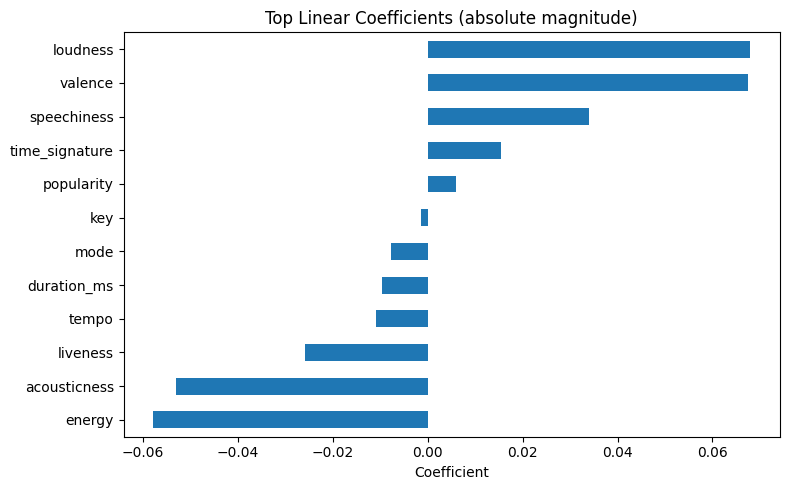

In [18]:
top_n = min(12, len(coefs))
plot_coefs = coefs.head(top_n).sort_values()

plt.figure(figsize=(8, 5))
plot_coefs.plot(kind="barh")
plt.title("Top Linear Coefficients (absolute magnitude)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()
